In [965]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [966]:
df=pd.read_excel("updated_TIR_dataset (1).xlsx", sheet_name="Sheet4", skiprows=1)

In [967]:
print(df.head(5))

   Unnamed: 0  Unnamed: 1  Unnamed: 2  Unnamed: 3              Patient  \
0         NaN         NaN         NaN         NaN         MDI/Pump/HCL   
1         NaN         NaN         NaN         NaN  High risk/ low risk   
2         NaN         NaN         NaN         NaN   Social deprivation   
3         NaN         NaN         NaN         NaN                 age    
4         NaN         NaN         NaN         NaN           ethnicity    

           1          2         3          4         5  ...       161  \
0        MDI        MDI       HCL       pump      pump  ...       NaN   
1  High risk  High risk  low risk  high risk  low risk  ...  low risk   
2        NaN        NaN       NaN        NaN       NaN  ...         4   
3        NaN        NaN       NaN        NaN       NaN  ...       NaN   
4        NaN        NaN       NaN        NaN       NaN  ...     black   

        162       163       164       165       166       167       168  \
0       NaN       NaN       NaN       NaN

In [968]:
df = df.drop(["Unnamed: 0", "Unnamed: 1", "Unnamed: 2",  "Unnamed: 3"], axis=1)  
print(df)


                Patient          1          2          3          4         5  \
0          MDI/Pump/HCL        MDI        MDI        HCL       pump      pump   
1   High risk/ low risk  High risk  High risk   low risk  high risk  low risk   
2    Social deprivation        NaN        NaN        NaN        NaN       NaN   
3                  age         NaN        NaN        NaN        NaN       NaN   
4            ethnicity         NaN        NaN        NaN        NaN       NaN   
5                   NaN        NaN        NaN        NaN        NaN       NaN   
6                   NaN        NaN        NaN        NaN        NaN       NaN   
7   2025-04-22 00:00:00        NaN        NaN        NaN         14       NaN   
8   2025-05-22 00:00:00        NaN        NaN        NaN          0       NaN   
9   2025-06-22 00:00:00        NaN        NaN        NaN          0        69   
10  2025-07-22 00:00:00        NaN        NaN        NaN         37        56   
11  2025-08-22 00:00:00     

In [969]:
# dividing the dataframe into  2 with iloc indexing 
df_patient_char=df.iloc[0:5]
df_patient_vals=df.iloc[7:]

<b>Fixing indentation in the dataframe </b>:

In [970]:
df_patient_char=df_patient_char.set_index("Patient")

In [971]:
df_patient_char.head()

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,High risk,low risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,2,1,1,3,10,3,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,black,other,black,white,white,white,white,black,black,black


<b> descriptive analysis of the data: </b>

In [972]:
df_patient_char.describe()

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
count,2,2,2,2,2,2,2,2,2,2,...,3,3,3,3,4,3,3,3,3,3
unique,2,2,2,2,2,2,2,2,2,2,...,3,3,3,3,4,3,3,3,3,3
top,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
freq,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [973]:
df_patient_char.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, MDI/Pump/HCL to ethnicity 
Columns: 170 entries, 1 to 170
dtypes: object(170)
memory usage: 6.7+ KB


In [974]:
df_patient_char.isnull().sum()

1      3
2      3
3      3
4      3
5      3
      ..
166    2
167    2
168    2
169    2
170    2
Length: 170, dtype: int64

In [975]:
df_patient_char.dtypes

1      object
2      object
3      object
4      object
5      object
        ...  
166    object
167    object
168    object
169    object
170    object
Length: 170, dtype: object

In [976]:
df_patient_char.duplicated()

Patient
MDI/Pump/HCL           False
High risk/ low risk    False
Social deprivation     False
age                    False
ethnicity              False
dtype: bool

 <b> Dropping all null values : </b>

In [977]:
# what to do with null values? 
# if all rows are empty no point in keeping them. 
# hence, removing all columns that have a NaN value of 

# drop a column if the column has more than 4 NaN values. 

df_patient_char= df_patient_char.dropna(axis=1, how='all')

In [978]:
df_patient_char

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,High risk,low risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,2,1,1,3,10,3,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,black,other,black,white,white,white,white,black,black,black


<b> for analysis: </b>

In [979]:
#missing data in each column: 
pp= df_patient_char.isnull().sum()
print(f"missing values in each patient are: \n {pp}")

# #missing data in all data frame:
missing=df_patient_char.isnull().sum().sum()
print(f"Total missing values are: \n {missing} ")

# missing measurements for each row: 
# to infer which rows have the highest missing values for the clinician 
nan_per_row = df_patient_char.isnull().sum(axis=1)
print(nan_per_row)


missing values in each patient are: 
 1      3
2      3
3      3
4      3
5      3
      ..
166    2
167    2
168    2
169    2
170    2
Length: 169, dtype: int64
Total missing values are: 
 371 
Patient
MDI/Pump/HCL           106
High risk/ low risk      2
Social deprivation      82
age                    118
ethnicity               63
dtype: int64


In [980]:
# Missing data per column

# Missing per column
missing_per_column = pd.DataFrame({
    'Column': df_patient_char.columns,
    'Missing_Count': df_patient_char.isnull().sum()
})

# Total missing
total_missing = df_patient_char.isnull().sum().sum()
print(f"Total missing data: {total_missing}")

# Missing per row
missing_per_row = pd.DataFrame({
    'Row_Index': range(len(df_patient_char)),
    'Missing_Count_Per_Row': df_patient_char.isnull().sum(axis=1)
})

print(missing_per_column)
print(missing_per_row)

Total missing data: 371
    Column  Missing_Count
1        1              3
2        2              3
3        3              3
4        4              3
5        5              3
..     ...            ...
166    166              2
167    167              2
168    168              2
169    169              2
170    170              2

[169 rows x 2 columns]
                     Row_Index  Missing_Count_Per_Row
Patient                                              
MDI/Pump/HCL                 0                    106
High risk/ low risk          1                      2
Social deprivation           2                     82
age                          3                    118
ethnicity                    4                     63


In [981]:
# missing values in each indicator 
df_patient_char.isnull().sum(axis=1)

Patient
MDI/Pump/HCL           106
High risk/ low risk      2
Social deprivation      82
age                    118
ethnicity               63
dtype: int64

In [982]:
df_patient_char.describe()

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
count,2,2,2,2,2,2,2,2,2,2,...,3,3,3,3,4,3,3,3,3,3
unique,2,2,2,2,2,2,2,2,2,2,...,3,3,3,3,4,3,3,3,3,3
top,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
freq,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [983]:
df_patient_vals=df_patient_vals.set_index("Patient")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [984]:
df_patient_vals.head(10)

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
2025-04-22,NaN,NaN,NaN,14,NaN,NaN,NaN,NaN,NaN,NaN,...,45,NaN,16,64,NaN,23,NaN,56,NaN,2
2025-05-22,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,49,NaN,9,68,NaN,10,NaN,21,NaN,5
2025-06-22,NaN,NaN,NaN,0,69,NaN,39,NaN,NaN,69,...,44,46,12,59,NaN,32,NaN,25,NaN,34
2025-07-22,NaN,NaN,NaN,37,56,NaN,37,NaN,NaN,69,...,53,45,23,69,NaN,NaN,NaN,24,NaN,6
2025-08-22,NaN,NaN,NaN,8,71,NaN,40,NaN,NaN,66,...,38,46,21,62,NaN,NaN,NaN,24,NaN,NaN
2025-09-22,NaN,NaN,NaN,NaN,59,NaN,33,NaN,NaN,65,...,47,43,14,64,NaN,NaN,NaN,21,NaN,4
2025-10-22,NaN,NaN,NaN,NaN,59,NaN,40,NaN,NaN,64,...,44,45,20,67,NaN,NaN,NaN,27,NaN,NaN
2025-11-22,NaN,NaN,NaN,NaN,52,34,36,NaN,NaN,61,...,44,47,18,74,NaN,NaN,NaN,11,NaN,0
2025-12-22,NaN,NaN,NaN,NaN,56,NaN,36,NaN,NaN,64,...,40,51,15,70,NaN,NaN,NaN,20,61,NaN


null values : 
- all null and text values will be converted into NaN

In [985]:
df_patient_vals.isnull().sum()

1      15
2      32
3      32
4      19
5       4
       ..
166    29
167    33
168     1
169    10
170     7
Length: 170, dtype: int64

In [986]:
df_patient_vals.dtypes

1      object
2      object
3      object
4      object
5      object
        ...  
166    object
167    object
168    object
169    object
170    object
Length: 170, dtype: object

checking if there are any columns with all values missing and removing them. There are some columns that are completely empty but have text values in them. I have planned on finding all text values first and then will either make them NaN or remove them if the patient has been excluded from the study. 

identifying text values in my data that are situated randomly in columns. Common text values include: 


In [987]:
# identifying text values 
# iterating over every cell value 
# use _replace to replace text with NaN


In [988]:
df_patient_vals

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
2025-04-22,NaN,NaN,NaN,14,NaN,NaN,NaN,NaN,NaN,NaN,...,45,NaN,16,64,NaN,23,NaN,56,NaN,2
2025-05-22,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,...,49,NaN,9,68,NaN,10,NaN,21,NaN,5
2025-06-22,NaN,NaN,NaN,0,69,NaN,39,NaN,NaN,69,...,44,46,12,59,NaN,32,NaN,25,NaN,34
2025-07-22,NaN,NaN,NaN,37,56,NaN,37,NaN,NaN,69,...,53,45,23,69,NaN,NaN,NaN,24,NaN,6
2025-08-22,NaN,NaN,NaN,8,71,NaN,40,NaN,NaN,66,...,38,46,21,62,NaN,NaN,NaN,24,NaN,NaN
2025-09-22,NaN,NaN,NaN,NaN,59,NaN,33,NaN,NaN,65,...,47,43,14,64,NaN,NaN,NaN,21,NaN,4
2025-10-22,NaN,NaN,NaN,NaN,59,NaN,40,NaN,NaN,64,...,44,45,20,67,NaN,NaN,NaN,27,NaN,NaN
2025-11-22,NaN,NaN,NaN,NaN,52,34,36,NaN,NaN,61,...,44,47,18,74,NaN,NaN,NaN,11,NaN,0
2025-12-22,NaN,NaN,NaN,NaN,56,NaN,36,NaN,NaN,64,...,40,51,15,70,NaN,NaN,NaN,20,61,NaN


In [989]:
all_text_values = {}

for col in df_patient_vals.columns:
    for index, row in df_patient_vals.iterrows():
        if isinstance(row[col], str):
            if row[col] in all_text_values:
                all_text_values[row[col]] += 1  
            else:
                all_text_values[row[col]] = 1   
            

for stats about missing data : 

In [990]:
all_text_values

{'no sensor': 7,
 'medtronic': 4,
 'no data': 34,
 'under UCLH': 1,
 'not linked to dexcom': 1,
 'FSL not linked': 1,
 '?dexcom': 1,
 'moved to Edinburgh - discharged': 1,
 'not accepted libreview invitation': 1}

nullifying all text values so that they'll be deleted automatically. 

In [991]:
df_patient_vals = df_patient_vals.replace(list(all_text_values.keys()), np.nan)

/var/folders/8p/x_3c3bpd4xnfmt67869t9cd80000gn/T/ipykernel_31469/192144101.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_patient_vals = df_patient_vals.replace(list(all_text_values.keys()), np.nan)


In [992]:
df_patient_vals= df_patient_vals.dropna(axis=1, how='all')
# dropping the null values. 

In [993]:
df_patient_vals

,1,4,5,6,7,8,9,10,11,12,...,160,161,162,163,164,165,166,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
2025-04-22,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,45,NaN,16,64,NaN,23.0,56.0,NaN,2.0
2025-05-22,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,49,NaN,9,68,NaN,10.0,21.0,NaN,5.0
2025-06-22,NaN,0.0,69.0,NaN,39.0,NaN,NaN,69.0,NaN,62.0,...,53.0,44,46.0,12,59,NaN,32.0,25.0,NaN,34.0
2025-07-22,NaN,37.0,56.0,NaN,37.0,NaN,NaN,69.0,NaN,54.0,...,48.0,53,45.0,23,69,NaN,NaN,24.0,NaN,6.0
2025-08-22,NaN,8.0,71.0,NaN,40.0,NaN,NaN,66.0,NaN,56.0,...,48.0,38,46.0,21,62,NaN,NaN,24.0,NaN,NaN
2025-09-22,NaN,NaN,59.0,NaN,33.0,NaN,NaN,65.0,58.0,63.0,...,56.0,47,43.0,14,64,NaN,NaN,21.0,NaN,4.0
2025-10-22,NaN,NaN,59.0,NaN,40.0,NaN,NaN,64.0,67.0,68.0,...,58.0,44,45.0,20,67,NaN,NaN,27.0,NaN,NaN
2025-11-22,NaN,NaN,52.0,34.0,36.0,NaN,NaN,61.0,67.0,62.0,...,47.0,44,47.0,18,74,NaN,NaN,11.0,NaN,0.0
2025-12-22,NaN,NaN,56.0,NaN,36.0,NaN,NaN,64.0,66.0,58.0,...,45.0,40,51.0,15,70,NaN,NaN,20.0,61.0,NaN


In [994]:
df_patient_vals.dtypes


1      float64
4      float64
5      float64
6      float64
7      float64
        ...   
165    float64
166    float64
168    float64
169    float64
170    float64
Length: 135, dtype: object

In [995]:
# highest and lowest TIR Values per patient 
least_TIR=df_patient_vals.min()
max_TIR=df_patient_vals.max()
print(f"Least recorded TIR per patient {least_recordings} \n")
print(f"Highest recorded TIR per patient {max_recordings} \n")

Least recorded TIR per patient Patient    2023-01-01 00:00:00
1                          4.0
4                          0.0
5                         52.0
6                          2.0
                  ...         
165                       24.0
166                       10.0
168                       11.0
169                       31.0
170                        0.0
Length: 136, dtype: object 

Highest recorded TIR per patient Patient    2025-12-22 00:00:00
1                         51.0
4                         69.0
5                         74.0
6                         34.0
                  ...         
165                       46.0
166                       70.0
168                       73.0
169                       65.0
170                       34.0
Length: 136, dtype: object 



In [996]:

# minimum and maximum values for each patient (column)
patient_based_TIR_stats= pd.DataFrame({
    'Lowest_TIR': df_patient_vals.min(),
    'Lowest_Date': df_patient_vals.idxmin(),
    'Highest_TIR': df_patient_vals.max(),
    'Highest_Date': df_patient_vals.idxmax(),
    'Mean':df_patient_vals.mean(),
    'Median':df_patient_vals.median(),
    'Skew':df_patient_vals.skew(),
    'kurtosis':df_patient_vals.kurt()
})

patient_based_TIR_stats

,Lowest_TIR,Lowest_Date,Highest_TIR,Highest_Date,Mean,Median,Skew,kurtosis
1,4.0,2023-09-01,51.0,2023-10-01,25.166667,24.0,0.256475,0.078145
4,0.0,2025-05-22,69.0,2023-03-01,32.538462,33.0,0.050094,-1.320652
5,52.0,2025-11-22,74.0,2023-05-01,62.448276,61.0,0.133665,-0.815035
6,2.0,2024-08-01,34.0,2025-11-22,10.166667,7.0,1.895125,3.565274
7,20.0,2023-10-01,45.0,2023-01-01,32.774194,32.0,0.168911,-0.330112
...,...,...,...,...,...,...,...,...
165,24.0,2023-04-01,46.0,2023-02-01,36.000000,38.0,-0.782152,NaN
166,10.0,2025-05-22,70.0,2024-09-01,33.750000,27.5,1.280842,1.987475
168,11.0,2025-11-22,73.0,2024-06-01,44.656250,45.0,-0.015429,-1.462467
169,31.0,2023-03-01,65.0,2023-07-01,53.391304,53.0,-0.720160,0.592666


code for beginning and ending values for each patient:

In [997]:
def first_last_values(df):
    result = {}

    for col in df.columns:
        first_idx = df[col].first_valid_index()
        last_idx = df[col].last_valid_index()

        result.update({ col :{"First_Entry": first_idx, "Last_Entry":last_idx}})
       
    return pd.DataFrame(result).T

first_last_vals = first_last_values(df_patient_vals)

first_last_vals

,First_Entry,Last_Entry
1,2023-01-01,2024-12-01
4,2025-04-22,2024-09-01
5,2025-06-22,2024-10-01
6,2025-11-22,2024-12-01
7,2025-06-22,2024-12-01
...,...,...
165,2023-02-01,2023-04-01
166,2025-04-22,2024-09-01
168,2025-04-22,2024-12-01
169,2025-12-22,2024-12-01


In [998]:
patient_based_TIR_stats


,Lowest_TIR,Lowest_Date,Highest_TIR,Highest_Date,Mean,Median,Skew,kurtosis
1,4.0,2023-09-01,51.0,2023-10-01,25.166667,24.0,0.256475,0.078145
4,0.0,2025-05-22,69.0,2023-03-01,32.538462,33.0,0.050094,-1.320652
5,52.0,2025-11-22,74.0,2023-05-01,62.448276,61.0,0.133665,-0.815035
6,2.0,2024-08-01,34.0,2025-11-22,10.166667,7.0,1.895125,3.565274
7,20.0,2023-10-01,45.0,2023-01-01,32.774194,32.0,0.168911,-0.330112
...,...,...,...,...,...,...,...,...
165,24.0,2023-04-01,46.0,2023-02-01,36.000000,38.0,-0.782152,NaN
166,10.0,2025-05-22,70.0,2024-09-01,33.750000,27.5,1.280842,1.987475
168,11.0,2025-11-22,73.0,2024-06-01,44.656250,45.0,-0.015429,-1.462467
169,31.0,2023-03-01,65.0,2023-07-01,53.391304,53.0,-0.720160,0.592666


In [999]:
patient_based_TIR_stats = first_last_vals.join(patient_based_TIR_stats)

patient_based_TIR_stats

,First_Entry,Last_Entry,Lowest_TIR,Lowest_Date,Highest_TIR,Highest_Date,Mean,Median,Skew,kurtosis
1,2023-01-01,2024-12-01,4.0,2023-09-01,51.0,2023-10-01,25.166667,24.0,0.256475,0.078145
4,2025-04-22,2024-09-01,0.0,2025-05-22,69.0,2023-03-01,32.538462,33.0,0.050094,-1.320652
5,2025-06-22,2024-10-01,52.0,2025-11-22,74.0,2023-05-01,62.448276,61.0,0.133665,-0.815035
6,2025-11-22,2024-12-01,2.0,2024-08-01,34.0,2025-11-22,10.166667,7.0,1.895125,3.565274
7,2025-06-22,2024-12-01,20.0,2023-10-01,45.0,2023-01-01,32.774194,32.0,0.168911,-0.330112
...,...,...,...,...,...,...,...,...,...,...
165,2023-02-01,2023-04-01,24.0,2023-04-01,46.0,2023-02-01,36.000000,38.0,-0.782152,NaN
166,2025-04-22,2024-09-01,10.0,2025-05-22,70.0,2024-09-01,33.750000,27.5,1.280842,1.987475
168,2025-04-22,2024-12-01,11.0,2025-11-22,73.0,2024-06-01,44.656250,45.0,-0.015429,-1.462467
169,2025-12-22,2024-12-01,31.0,2023-03-01,65.0,2023-07-01,53.391304,53.0,-0.720160,0.592666


In [1000]:
df_patient_char

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,High risk,low risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,2,1,1,3,10,3,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,black,other,black,white,white,white,white,black,black,black


In [1001]:
df_patient_char.loc['MDI/Pump/HCL',:]

1       MDI
2       MDI
3       HCL
4      pump
5      pump
       ... 
166     NaN
167     NaN
168     NaN
169     NaN
170     NaN
Name: MDI/Pump/HCL, Length: 169, dtype: object

In [1002]:
# for patient vs performance metric calculation; 
#  create a copy of df_patient_char
# keeep mdi/hcl/puump row 
# delete the rest 
# keep dates 
# merge , 
#  null values ? different null values in both data frames


# which drug performed better over time?
# line graph 


In [1003]:
df_patient_char.head()

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,High risk,low risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,2,1,1,3,10,3,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,black,other,black,white,white,white,white,black,black,black


In [1004]:
df_treatment = df_patient_char.reset_index().copy().set_index("Patient")
# df_treatment = df_treatment.loc[['MDI/Pump/HCL']]  # keep only treatment row
df_treatment

,1,2,3,4,5,6,7,8,9,10,...,161,162,163,164,165,166,167,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,MDI,HCL,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,High risk,low risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,2,1,1,3,10,3,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,black,other,black,white,white,white,white,black,black,black


In [1005]:
df_treatment.columns

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       161, 162, 163, 164, 165, 166, 167, 168, 169, 170],
      dtype='object', length=169)

In [1006]:
df_patient_vals_copy = df_patient_vals.reset_index().copy().set_index("Patient")
df_patient_vals_copy.columns

Index([  1,   4,   5,   6,   7,   8,   9,  10,  11,  12,
       ...
       160, 161, 162, 163, 164, 165, 166, 168, 169, 170],
      dtype='object', length=135)

In [1007]:
complete = pd.concat([df_treatment, df_patient_vals_copy], axis=0, join="inner")

complete

,1,4,5,6,7,8,9,10,11,12,...,160,161,162,163,164,165,166,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,pump- upgraded to HCL July 24,MDI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,high risk,low risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9,4,2,1,1,3,10,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,white,black,other,black,white,white,white,black,black,black
2025-04-22 00:00:00,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,45,NaN,16,64,NaN,23.0,56.0,NaN,2.0
2025-05-22 00:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,49,NaN,9,68,NaN,10.0,21.0,NaN,5.0
2025-06-22 00:00:00,NaN,0.0,69.0,NaN,39.0,NaN,NaN,69.0,NaN,62.0,...,53.0,44,46.0,12,59,NaN,32.0,25.0,NaN,34.0
2025-07-22 00:00:00,NaN,37.0,56.0,NaN,37.0,NaN,NaN,69.0,NaN,54.0,...,48.0,53,45.0,23,69,NaN,NaN,24.0,NaN,6.0


In [1008]:
complete.head(10)

,1,4,5,6,7,8,9,10,11,12,...,160,161,162,163,164,165,166,168,169,170
Patient,,,,,,,,,,,,,,,,,,,,,
MDI/Pump/HCL,MDI,pump,pump,MDI,MDI,MDI,MDI,Pump- Upgraded to HCL in Nov 23,pump- upgraded to HCL July 24,MDI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
High risk/ low risk,High risk,high risk,low risk,High risk,low risk,low risk,high risk,high risk,high risk,low risk,...,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,low risk,high risk
Social deprivation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9,4,2,1,1,3,10,2,2,3
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,25,NaN,NaN,NaN,NaN,23,NaN,NaN,NaN,NaN
ethnicity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,white,black,other,black,white,white,white,black,black,black
2025-04-22 00:00:00,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,45,NaN,16,64,NaN,23.0,56.0,NaN,2.0
2025-05-22 00:00:00,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,49,NaN,9,68,NaN,10.0,21.0,NaN,5.0
2025-06-22 00:00:00,NaN,0.0,69.0,NaN,39.0,NaN,NaN,69.0,NaN,62.0,...,53.0,44,46.0,12,59,NaN,32.0,25.0,NaN,34.0
2025-07-22 00:00:00,NaN,37.0,56.0,NaN,37.0,NaN,NaN,69.0,NaN,54.0,...,48.0,53,45.0,23,69,NaN,NaN,24.0,NaN,6.0


In [1034]:
n_meta = 5

# Metadata rows at the top
meta = (
    complete.iloc[:n_meta]
    .T
    .rename_axis("Patient")
    .reset_index()
)

# Date rows
data = complete.iloc[n_meta:].copy()

long_data = (
    data
    .rename_axis("date")
    .reset_index()
    .melt(
        id_vars="date",
        var_name="Patient",
        value_name="TIR"    # time in range 
    )
)
final_df = long_data.merge(meta, on="Patient", how="left")

final_df.head(50)

,date,Patient,TIR,MDI/Pump/HCL,High risk/ low risk,Social deprivation,age,ethnicity
0,2025-04-22,1,NaN,MDI,High risk,NaN,NaN,NaN
1,2025-05-22,1,NaN,MDI,High risk,NaN,NaN,NaN
2,2025-06-22,1,NaN,MDI,High risk,NaN,NaN,NaN
3,2025-07-22,1,NaN,MDI,High risk,NaN,NaN,NaN
4,2025-08-22,1,NaN,MDI,High risk,NaN,NaN,NaN
5,2025-09-22,1,NaN,MDI,High risk,NaN,NaN,NaN
6,2025-10-22,1,NaN,MDI,High risk,NaN,NaN,NaN
7,2025-11-22,1,NaN,MDI,High risk,NaN,NaN,NaN
8,2025-12-22,1,NaN,MDI,High risk,NaN,NaN,NaN
9,2023-01-01,1,24.0,MDI,High risk,NaN,NaN,NaN


In [1010]:
# missing_treatment = final_df['MDI/Pump/HCL'].isna().sum()
# has_treatment     = final_df['MDI/Pump/HCL'].notna().sum()

# plt.figure(figsize=(5, 5))
# plt.pie(
#     [has_treatment, missing_treatment],
#     labels=[f'Treatment mentioned\n{has_treatment}',
#             f'Treatment not mentioned\n{missing_treatment}'],
#     colors=['yellow', 'red'],
#     autopct='%1.1f%%',
#     startangle=90,
#     wedgeprops={'edgecolor': 'white', 'linewidth': 2}
# )
# plt.title('Patient Treatment Indicator Summary')
# plt.show()


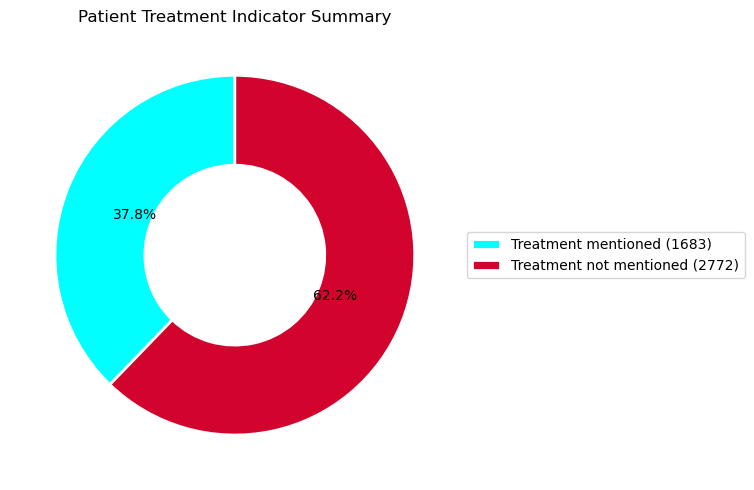

In [1011]:
# Patients with treatment label
has_treatment = final_df['MDI/Pump/HCL'].notna().sum()

# Patients with no treatment label but have TIR data
missing_treatment = final_df['MDI/Pump/HCL'].isna().sum()


fig, ax = plt.subplots(figsize=(7, 5))

wedges, texts, autotexts = ax.pie(
    [has_treatment, missing_treatment ],
    colors=[ 'cyan', '#D2042D'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.5}
)

ax.legend(
    wedges,
    [f'Treatment mentioned ({has_treatment})',
     f'Treatment not mentioned ({missing_treatment})'],
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

ax.set_title('Patient Treatment Indicator Summary')
plt.tight_layout()
plt.show()

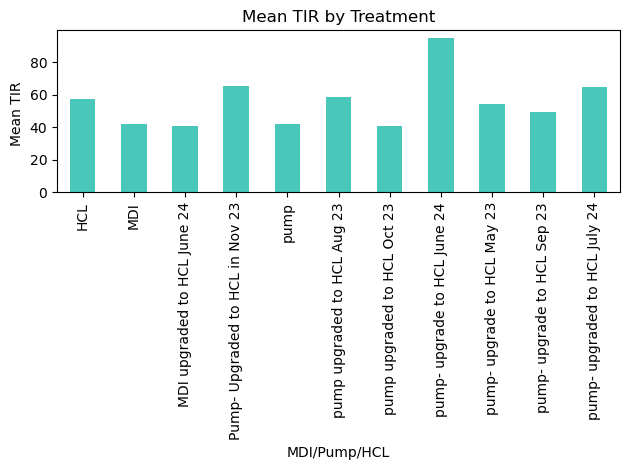

In [1012]:
grouped=final_df.groupby(["MDI/Pump/HCL"]).agg({"TIR": ["mean", "min"]})
# final_df.plot.bar(x="MDI/Pump/HCL", color='blue,yellow,green')
# Plot mean TIR by treatment
grouped['TIR']['mean'].plot.bar(color=['#48C7BA'])
plt.ylabel('Mean TIR ')
plt.title('Mean TIR by Treatment')
plt.tight_layout()
plt.show()


In [1013]:
final_df.shape[0]
# returns no of rows 

4455

Present and Missing values per Patient: 

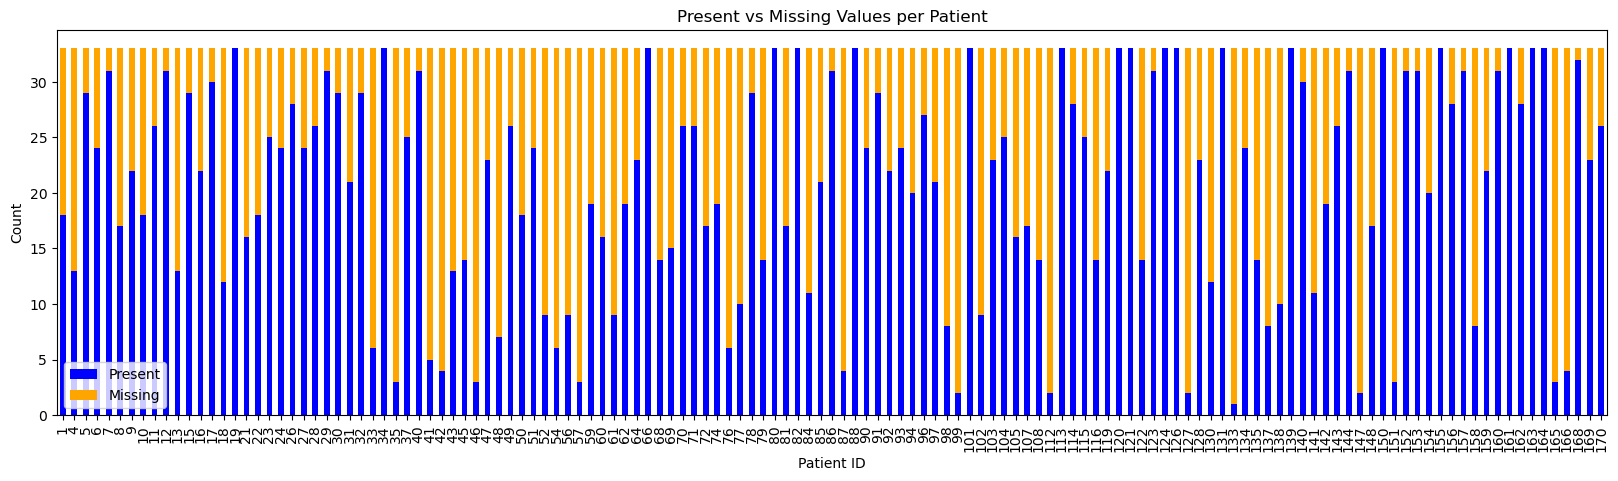

In [1014]:
missing_vals = df_patient_vals.isnull().sum()
present = df_patient_vals.notna().sum()

avg_missing=(df_patient_vals.isnull().sum())

pd.DataFrame({'Present': present, 'Missing': missing_vals}).plot(
    kind='bar', 
    stacked=True, 
    figsize=(20, 5),
    color=['blue', 'orange']
)
plt.title('Present vs Missing Values per Patient')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.show()

In [1015]:
df_patient_vals.count().sum()

np.int64(2776)

Missing values after data cleaning: 
- all patients where TIR values were completely null were removed. 
- columns with all null treatment/age/risk/ethnicity/social deprivation were removed . 

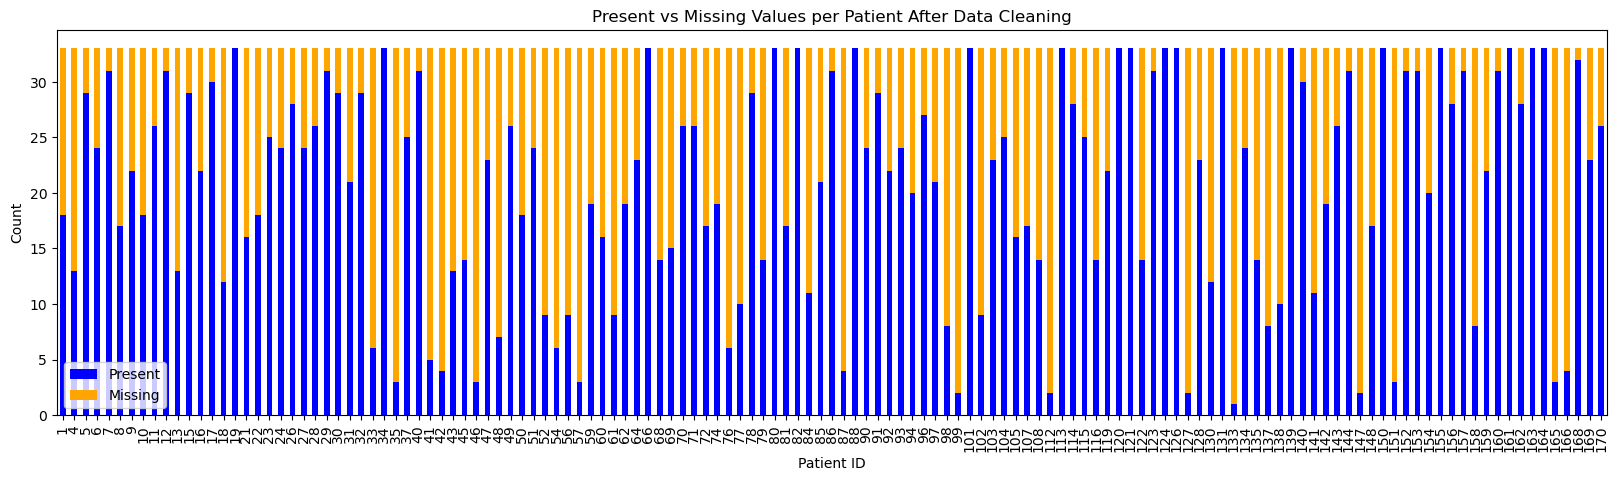

In [1016]:
#  plot null values from complete df. 


missing_vals_complete = final_df.isnull().sum()
present_complete = final_df.notna().sum()

pd.DataFrame({'Present': present, 'Missing': missing_vals}).plot(
    kind='bar', 
    stacked=True, 
    figsize=(20, 5),
    color=['blue', 'orange']
)
plt.title('Present vs Missing Values per Patient After Data Cleaning')
plt.xlabel('Patient ID')
plt.ylabel('Count')
plt.show()

Patient vs treatement measure: 
- group into Pump , HCL , MDI 
- treatment performance? 

TypeError: Could not convert ['HCLMDIMDI upgraded to HCL June 24Pump- Upgraded to HCL in Nov 23pumppump upgraded to HCL Aug 23pump upgraded to HCL Oct 23pump- upgrade to HCL June 24pump- upgrade to HCL May 23pump- upgrade to HCL Sep 23pump- upgraded to HCL July 24'] to numeric

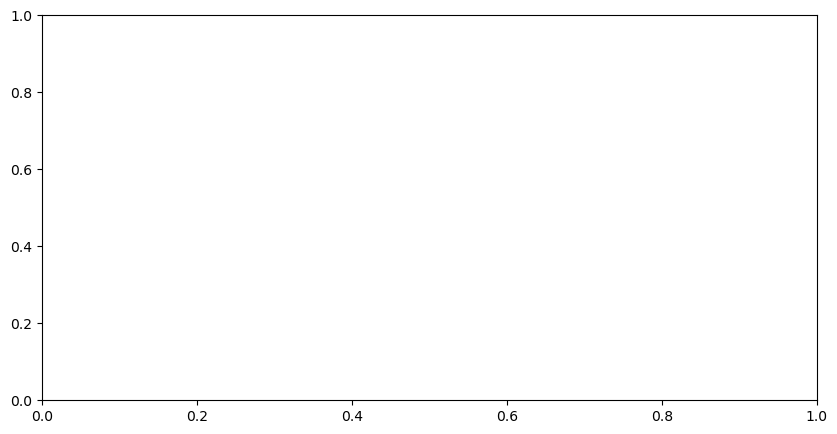

In [1048]:
# grouped=final_df.groupby(["MDI/Pump/HCL"]).agg({"TIR": ["sum"]})
grouped = (
    final_df
    .dropna(subset=["TIR", "MDI/Pump/HCL"])
    .groupby("MDI/Pump/HCL")
    .agg(
        total_TIR=("TIR", "sum"),
        mean_TIR=("TIR", "mean"),
        readings_count=("TIR", "count")
    )
)

grouped["TIR_share"] = grouped["total_TIR"] / grouped["total_TIR"].sum() * 100

grouped = grouped.reset_index()

grouped.sort_values("TIR_share", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(grouped,  bins=20, color="#3015DE", alpha=0.6, label=f'MDI  (mean={round(grouped.mean(),1)})')
ax.hist(grouped, bins=20, color="#FFE600", alpha=0.6, label=f'Pump (mean={round(grouped.mean(),1)})')
ax.hist(grouped,  bins=20, color="#FA0921", alpha=0.6, label=f'HCL  (mean={round(grouped.mean(),1)})')

ax.set_xlabel('TIR ')
ax.set_ylabel('Number of readings')
ax.set_title('Distribution of TIR Readings by Treatment Type')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()





In [1062]:
final_df.groupby(["date", "MDI/Pump/HCL"]).agg(
    mean_TIR=("TIR", "mean"),
    readings_count=("TIR", "count"),
    readings_sum=("TIR", "sum")
)

mean_TIR  readings_count  \
date       MDI/Pump/HCL                                                 
2023-01-01 HCL                                   57.5               4   
           MDI                              37.157895              19   
           MDI upgraded to HCL June 24           34.0               1   
           Pump- Upgraded to HCL in Nov 23       63.0               1   
           pump                             45.833333               6   
...                                               ...             ...   
2025-12-22 pump upgraded to HCL Oct 23            NaN               0   
           pump- upgrade to HCL June 24           NaN               0   
           pump- upgrade to HCL May 23           50.0               1   
           pump- upgrade to HCL Sep 23           29.0               1   
           pump- upgraded to HCL July 24         66.0               1   

                                           readings_sum  
date       MDI/Pump/HCL                                  
2023-01-01 HCL                                    230.0  
           MDI                                    706.0  
           MDI upgraded to HCL June 24             34.0  
           Pump- Upgraded to HCL in Nov 23         63.0  
           pump                                   275.0  
...                                                 ...  
2025-12-22 pump upgraded to HCL Oct 23                0  
           pump- upgrade to HCL June 24               0  
           pump- upgrade to HCL May 23             50.0  
           pump- upgrade to HCL Sep 23             29.0  
           pump- upgraded to HCL July 24           66.0  

[363 rows x 3 columns]

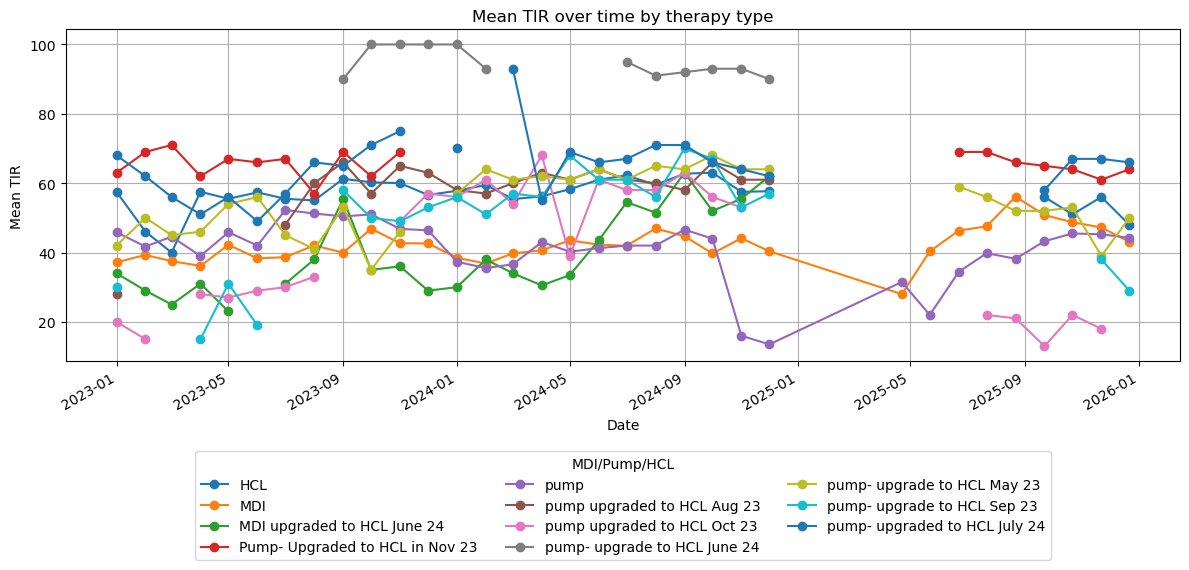

In [1058]:
# Ensure date is datetime
final_df2 = final_df.copy()
final_df2["date"] = pd.to_datetime(final_df["date"])

summary = (
    final_df2
    .groupby(["date", "MDI/Pump/HCL"])
    .agg(
        mean_TIR=("TIR", "mean"),
        readings_count=("TIR", "count")
    )
    .reset_index()
    .sort_values("date")
)

# Plot mean TIR over time
pivot_tir = summary.pivot(
    index="date",
    columns="MDI/Pump/HCL",
    values="mean_TIR"
)

ax = pivot_tir.plot(
    figsize=(12, 6),
    marker="o"
)

ax.set_title("Mean TIR over time by therapy type")
ax.set_xlabel("Date")
ax.set_ylabel("Mean TIR")
ax.legend(title="MDI/Pump/HCL")
ax.grid(True)

ax.legend(
    title="MDI/Pump/HCL",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3
)

plt.tight_layout()
plt.show()

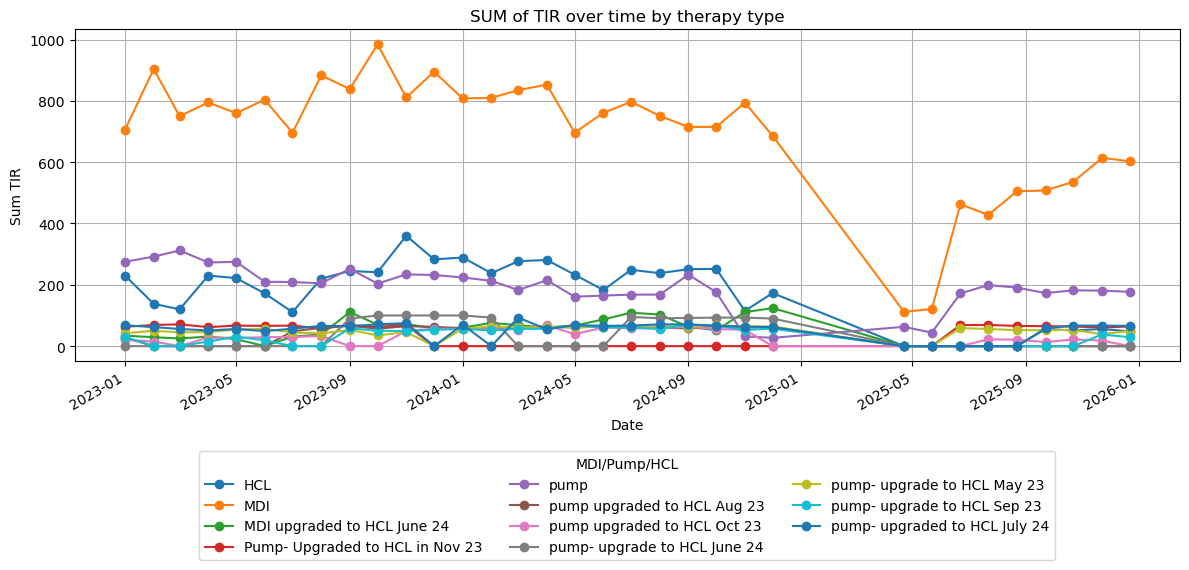

In [ ]:
# Ensure date is datetime
final_df2 = final_df.copy()
final_df2["date"] = pd.to_datetime(final_df["date"])

summary = (
    final_df2
    .groupby(["date", "MDI/Pump/HCL"])
    .agg(
        readings_sum=("TIR", "sum")
    )
    .reset_index()
    .sort_values("date")
)

# Plot mean TIR over time
pivot_tir = summary.pivot(
    index="date",
    columns="MDI/Pump/HCL",
    values="readings_sum"
)

ax = pivot_tir.plot(
    figsize=(12, 6),
    marker="o"
)

ax.set_title("SUM of TIR over time by treatment type")
ax.set_xlabel("Date")
ax.set_ylabel("Sum TIR")
ax.legend(title="MDI/Pump/HCL")
ax.grid(True)

ax.legend(
    title="MDI/Pump/HCL",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3
)

plt.tight_layout()
plt.show()

standard deviation - consistency of control 

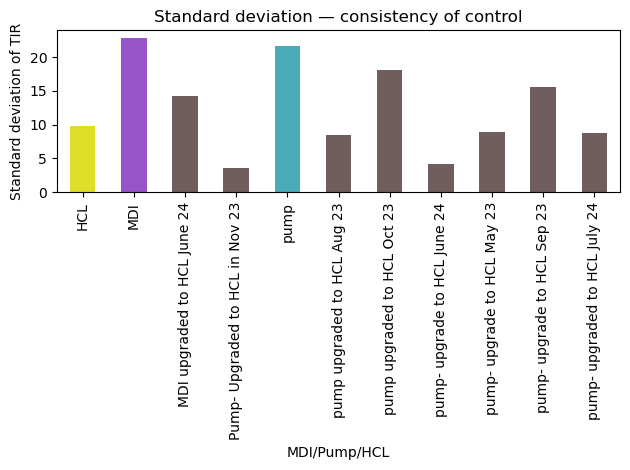

In [1017]:
grouped=final_df.groupby(["MDI/Pump/HCL"]).agg({"TIR": ["std"]})
label_color_map = {
    'MDI': '#9853C9',
    'pump': "#49ABB8",
    'HCL': '#DEDE28'
}


ax = grouped['TIR']['std'].plot.bar(
    color=[label_color_map.get(label, '#705E5E') for label in grouped.index]
)


plt.ylabel('Standard deviation of TIR')
plt.title('Standard deviation — consistency of control')
plt.tight_layout()
plt.show()

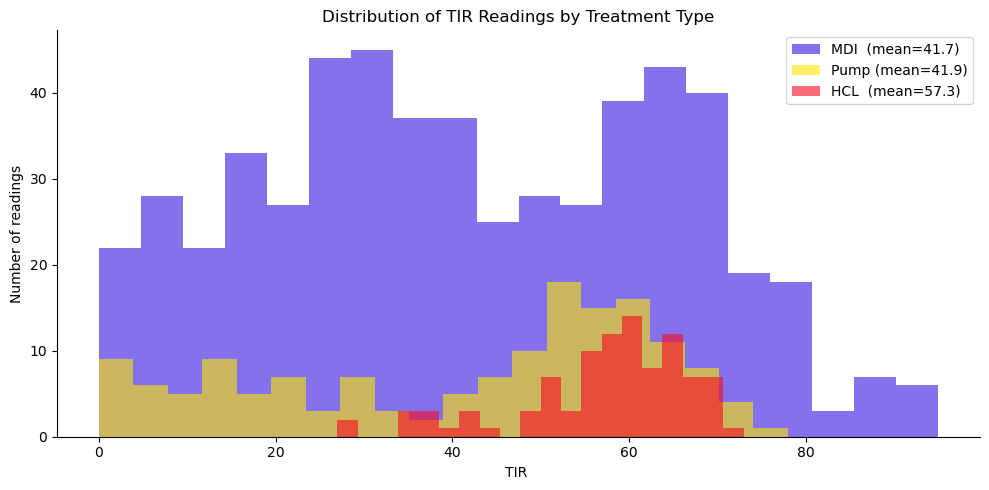

In [1028]:

# Calculate TIR values per treatment from your final_df
mdi_vals  = final_df[final_df['MDI/Pump/HCL'] == 'MDI']['TIR'].dropna()
pump_vals = final_df[final_df['MDI/Pump/HCL'] == 'pump']['TIR'].dropna()
hcl_vals  = final_df[final_df['MDI/Pump/HCL'] == 'HCL']['TIR'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

# Plot overlapping histograms
ax.hist(mdi_vals,  bins=20, color="#3015DE", alpha=0.6, label=f'MDI  (mean={round(mdi_vals.mean(),1)})')
ax.hist(pump_vals, bins=20, color="#FFE600", alpha=0.6, label=f'Pump (mean={round(pump_vals.mean(),1)})')
ax.hist(hcl_vals,  bins=20, color="#FA0921", alpha=0.6, label=f'HCL  (mean={round(hcl_vals.mean(),1)})')



ax.set_xlabel('TIR ')
ax.set_ylabel('Number of readings')
ax.set_title('Distribution of TIR Readings by Treatment Type')
ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

In [1065]:

# Calculate stats from your final_df
# treatments = ['MDI', 'pump', 'HCL']
# labels     = ['MDI', 'Pump', 'HCL']
# colors     = ["#213187", "#213187", "#213187"]

# mean_tir, pct_good, pct_poor = [], [], []

# for tx in treatments:
#     vals = final_df[final_df['MDI/Pump/HCL'] == tx]['TIR'].dropna()
#     mean_tir.append(round(vals.mean(), 1))
#     pct_good.append(round((vals >= 70).sum() / len(vals) * 100, 1))
#     pct_poor.append(round((vals < 50).sum() / len(vals) * 100, 1))

# x     = np.arange(len(labels))
# width = 0.25

# fig, ax = plt.subplots(figsize=(10, 5))

# bars1 = ax.bar(x - width, mean_tir,  width, color=colors, alpha=1.0,  label='Mean TIR %')
# bars2 = ax.bar(x,         pct_good,  width, color=colors, alpha=0.6,  label='% readings ≥70% (good)')
# bars3 = ax.bar(x + width, pct_poor,  width, color=colors, alpha=0.3,  label='% readings <50% (poor)')

# # # Value labels on each bar
# for bars in [bars1, bars2, bars3]:
#     for bar in bars:
#         ax.text(bar.get_x() + bar.get_width()/2,
#                 bar.get_height() + 0.5,
#                 f'{bar.get_height()}%',
#                 ha='center', fontsize=9)

# ax.set_xticks(x)
# ax.set_xticklabels(labels, fontsize=11)
# ax.set_ylabel('Percentage (%)')
# ax.set_ylim(0, 110)
# ax.set_title('Treatment Performance Comparison', fontsize=13, fontweight='bold')
# ax.axhline(70, color='red', linestyle='--', linewidth=1, label='70% target')
# ax.legend(fontsize=9)
# ax.spines[['top','right']].set_visible(False)
# ax.yaxis.grid(True, linestyle='--', alpha=0.4)
# ax.set_axisbelow(True)
# plt.tight_layout()
# plt.show()